# dr_evt 04: a mini federation, routers over N platforms

Sessions 01-03 were about dr_evt as it is. This session assembles the smallest version of
what we are going to build in it: four platforms, each a dr_evt session with its own node
count and speed, one client that owns the arrivals and the clock, a start-time prediction
built from the backfill window, two routers that decide which platform each job goes to,
and service metrics computed from the per-job records. It is the skeleton of the federated market client with everything market-related left out. Route mode only: the
client submits, dr_evt's EASY decides when a job starts.

About 150 lines. Read it as the skeleton the real `dr_evt_market` package fleshes out.

In [1]:
from pathlib import Path
from dataclasses import dataclass, field
import subprocess, socket, sys, os, tempfile, math
import numpy as np
import pandas as pd

DR_EVT = Path.cwd().resolve()                        # run from learn/ or from the repository root
while not (DR_EVT / "CMakeLists.txt").exists() and DR_EVT != DR_EVT.parent:
    DR_EVT = DR_EVT.parent
assert (DR_EVT / "CMakeLists.txt").exists(), "run this notebook from learn/ inside a dr_evt checkout"
INSTALL = Path(os.environ.get("DR_EVT_INSTALL", DR_EVT / "install"))   # the cmake install prefix
OUT = Path.cwd() / "output"                                            # scratch space, gitignored
OUT.mkdir(exist_ok=True)
SERVER_BIN = INSTALL / "bin" / "dr_evt_server"
sys.path.insert(0, str(DR_EVT / "python"))
from grpc_multi_server import load_stubs, ServerSession, DEFAULT_QUEUE_INPUT
QUEUE = DEFAULT_QUEUE_INPUT      # "1" in the default numeric queue-id mode

grpc, pb, service, generated_dir = load_stubs(DR_EVT)
HEADER_ONLY = OUT / "header_only.csv"
HEADER_ONLY.write_text("job_submit_time,num_nodes,queue,time_limit\n")

def free_port():
    with socket.socket() as s:
        s.bind(("127.0.0.1", 0)); return s.getsockname()[1]

SERVER_DIR = Path(tempfile.mkdtemp(dir=OUT, prefix="federation_"))
ADDRESS = f"127.0.0.1:{free_port()}"
server = subprocess.Popen([str(SERVER_BIN), ADDRESS], cwd=SERVER_DIR,
                          stdout=(SERVER_DIR / "server.log").open("w"), stderr=subprocess.STDOUT)
ch = grpc.insecure_channel(ADDRESS); grpc.channel_ready_future(ch).result(timeout=15); ch.close()
print("server on", ADDRESS, "writing to", SERVER_DIR.relative_to(Path.cwd()))

server on 127.0.0.1:64437 writing to output/federation_naprnh_1


## 1. The platform adapter

One object per platform with the interface the market client uses, backed by a gRPC
session. It enforces the two client-side guards from notebook 02 (no oversize jobs, submit
times never behind the platform clock) and keeps a ledger of what it submitted so it can
map the output CSV rows back to handles and predict releases when dr_evt's window is
silent.

In [2]:
@dataclass
class PlatformSpec:
    name: str
    total_nodes: int      # the federation slice
    rel_runtime: float    # runtime multiplier vs lassen (0.125 = 8x faster)
    has_gpu: bool

@dataclass
class Submission:
    handle: int           # dr_evt job_idx
    job_id: int
    submit_s: int
    nodes: int
    limit_s: int
    predicted_start_s: int

class GrpcPlatform:
    def __init__(self, spec, session_name):
        self.spec, self.now = spec, 0
        self.session = ServerSession(ADDRESS, grpc, pb, service)
        self.init = self.session.call(pb.ClientMessage(init=pb.InitRequest(
            session_name=session_name, total_nodes=spec.total_nodes, trace_format="simple",
            timestamp_format="epoch", backfill_policy="easy", priority_policy="fcfs",
            run_time_mode="limit", queue_impl="circular", msec_output=True, infile=str(HEADER_ONLY)))).init
        self.ledger = []

    def limit_for(self, runtime_on_lassen_s):
        return int(math.ceil(runtime_on_lassen_s * self.spec.rel_runtime))   # dr_evt truncates to whole seconds

    def fits(self, job):
        return job.nodes <= self.spec.total_nodes and (self.spec.has_gpu or not job.gpu_required)

    def advance_to(self, t):
        assert t >= self.now
        self.session.call(pb.ClientMessage(advance_to=pb.AdvanceToRequest(target_time=float(t))))
        self.now = t

    def window(self):
        return self.session.call(pb.ClientMessage(get_backfill_window=pb.GetBackfillWindowRequest())).get_backfill_window

    def submit(self, job, t, predicted_start):
        assert self.fits(job) and t >= self.now                       # oversize and clock guards
        limit = self.limit_for(job.runtime_lassen_s)
        r = self.session.call(pb.ClientMessage(append_job=pb.AppendJobRequest(
            submit_time=float(t), num_nodes=job.nodes, queue=QUEUE, limit_time=float(limit))))
        self.ledger.append(Submission(r.append_job.job_idx, job.job_id, t, job.nodes, limit, predicted_start))
        self.advance_to(t)                                             # evaluate the arrival now

    def finish(self):
        fin = self.session.call(pb.ClientMessage(finish_simulation=pb.FinishSimulationRequest())).finish_simulation
        self.session.close()
        records = pd.read_csv(SERVER_DIR / fin.simulated_trace_file)
        assert len(records) == len(self.ledger), "positional matching needs zero rejections"
        for col, vals in {"platform": self.spec.name, "job_id": [s.job_id for s in self.ledger],
                          "predicted_start": [s.predicted_start_s for s in self.ledger]}.items():
            records[col] = vals
        return records

## 2. Start-time prediction from the backfill window

Plan section 4.3, verbatim. The window gives `available_nodes`, the head's `shadow_time`
(`-1` when nothing waits) and the projected `releases` up to the shadow time. When nothing
waits the window has no releases, so the fallback walks the platform's own ledger: every
submitted job's `predicted_start + limit` is a projected release. It is the same time-limit
projection EASY itself uses, and it is optimistic in exactly the same way.

In [3]:
def predict_start(platform, nodes, limit, now):
    w = platform.window()
    if w.shadow_time < 0:                                   # nothing waiting on this platform
        if nodes <= w.available_nodes:
            return now, "now"
        releases = [(r.time, r.nodes_released) for r in w.releases]
        if not releases:                                    # dr_evt is silent here: use our ledger
            releases = sorted((s.predicted_start_s + s.limit_s, s.nodes) for s in platform.ledger
                              if s.predicted_start_s + s.limit_s > now)
        free = w.available_nodes
        for t, n in releases:
            free += n
            if free >= nodes:
                return int(t), "after_release"
        return None, "unknown"
    if nodes <= w.available_nodes and now + limit < w.shadow_time:
        return now, "backfill"
    return int(w.shadow_time), "behind_head"                # optimistic: it queues behind the head

## 3. The federation and a synthetic workload

The four benchmark slices (federation shares of the real machines) with rough relative
runtimes from our platform model, and 200 synthetic jobs over about 100 minutes, dense enough
to saturate the fast platforms. Half need a GPU, which rules out dane. Everything is integer seconds.

In [4]:
FLEET = [PlatformSpec("dane", 308, 2.0, has_gpu=False), PlatformSpec("lassen", 159, 1.0, has_gpu=True),
         PlatformSpec("tioga", 16, 1 / 6, has_gpu=True), PlatformSpec("tuolumne", 230, 1 / 8, has_gpu=True)]

@dataclass(frozen=True)
class Job:
    job_id: int
    submit_s: int
    nodes: int
    runtime_lassen_s: int
    gpu_required: bool

def synthetic_workload(n=200, seed=7):
    rng = np.random.default_rng(seed)
    t = np.cumsum(rng.exponential(30.0, size=n)).astype(int)
    nodes = rng.choice([2, 4, 8, 16, 32, 64, 96], size=n, p=[.15, .20, .20, .20, .15, .07, .03])
    runtime = np.clip(rng.lognormal(np.log(3600), 0.8, size=n), 300, 14400).astype(int)
    gpu = rng.random(n) < 0.5
    return [Job(i, int(t[i]), int(nodes[i]), int(runtime[i]), bool(gpu[i])) for i in range(n)]

jobs = synthetic_workload()
pd.DataFrame(jobs).describe().loc[["mean", "50%", "max"]]

,job_id,submit_s,nodes,runtime_lassen_s
mean,99.5,3114.835,18.27,3974.17
50%,99.5,3051.500,8.00,3189.50
max,199.0,6174.000,96.00,14400.00


## 4. Two routers

Both decide at arrival time, immediately, like a production federation would. `first_feasible` takes the first platform in registry order that fits.
`min_turnaround` asks every feasible platform for a predicted start, adds that platform's
runtime, and takes the smallest turnaround. The second one is our EASY baseline's new
shape: no windows, no bids, just dr_evt's own reservation state feeding a greedy choice.

In [5]:
def route_first_feasible(job, platforms, now):
    for p in platforms:
        if p.fits(job):
            start, _ = predict_start(p, job.nodes, p.limit_for(job.runtime_lassen_s), now)
            return p, (start if start is not None else now)
    raise RuntimeError("structurally infeasible job")

def route_min_turnaround(job, platforms, now):
    best = None
    for p in platforms:
        if not p.fits(job):
            continue
        limit = p.limit_for(job.runtime_lassen_s)
        start, why = predict_start(p, job.nodes, limit, now)
        start = start if start is not None else now + 10 ** 6          # unknown: rank last
        turnaround = start + limit - now
        if best is None or turnaround < best[0]:
            best = (turnaround, p, start)
    _, p, start = best
    return p, start

## 5. The controller loop

Plan section 4.4 without windows: for each arrival, advance every platform to it (they are
independent, no coupling), route, submit. Then finish every session, collect the per-job
records, and fold the metrics: wait, bounded slowdown with the benchmark's 300 s floor,
per-platform utilization, and the gap between predicted and realized start.

In [6]:
def run_federation(router, label):
    platforms = [GrpcPlatform(spec, f"{label}-{spec.name}") for spec in FLEET]
    for job in sorted(jobs, key=lambda j: j.submit_s):
        for p in platforms:
            p.advance_to(job.submit_s)
        chosen, predicted = router(job, platforms, job.submit_s)
        chosen.submit(job, job.submit_s, predicted)
    records = pd.concat([p.finish() for p in platforms], ignore_index=True)
    records["wait"] = records.begin_time - records.job_submit_time
    records["runtime"] = records.end_time - records.begin_time
    records["bsld"] = ((records.end_time - records.job_submit_time) / records.runtime.clip(lower=300)).clip(lower=1.0)
    records["prediction_error"] = records.begin_time - records.predicted_start
    horizon = records.end_time.max()
    util = {spec.name: (records[records.platform == spec.name].eval("num_nodes * runtime").sum()
                        / (spec.total_nodes * horizon)) for spec in FLEET}
    summary = {"router": label, "jobs": len(records), "wait mean (s)": records.wait.mean(),
               "wait p95 (s)": records.wait.quantile(0.95), "bsld mean": records.bsld.mean(),
               "makespan (s)": horizon, "prediction error mean (s)": records.prediction_error.mean(),
               "prediction error max (s)": records.prediction_error.max(),
               **{f"util {k}": v for k, v in util.items()}}
    return records, summary

rec_ff, sum_ff = run_federation(route_first_feasible, "firstfit")
rec_mt, sum_mt = run_federation(route_min_turnaround, "minturn")
pd.DataFrame([sum_ff, sum_mt]).set_index("router").T

router,firstfit,minturn
jobs,200.000000,200.000000
wait mean (s),13180.070000,290.040000
wait p95 (s),32240.350000,1130.050000
bsld mean,4.376940,1.574941
makespan (s),69339.000000,8561.000000
prediction error mean (s),12382.815000,236.290000
prediction error max (s),38202.000000,1324.000000
util dane,0.724467,0.000000
util lassen,0.531444,0.000000
util tioga,0.000000,0.317574


In [7]:
pd.concat([rec_ff.assign(router="first_feasible"), rec_mt.assign(router="min_turnaround")]) \
  .groupby(["router", "platform"]).agg(jobs=("job_id", "size"), wait_mean=("wait", "mean"),
                                        bsld_mean=("bsld", "mean"), pred_err_max=("prediction_error", "max"))

jobs     wait_mean bsld_mean pred_err_max
router         platform                                           
first_feasible dane        94  14657.414894  3.648718      38202.0
               lassen     106  11869.971698  5.022723      29978.0
min_turnaround tioga       20         30.45  1.088188        397.0
               tuolumne   180    318.883333  1.629024       1324.0

Read the two tables together. `first_feasible` dumps everything that fits onto dane
(slow, CPU only) and only sends GPU jobs elsewhere; `min_turnaround` moves work to the fast
platforms until their predicted starts slip, which is where the prediction error appears:
a positive error means EASY started the job later than the client's optimistic estimate,
which happens when the job queued behind a head or when a same-window sibling took the
nodes first. That error column is a first-class metric in the market client; if it is
large in the real world, extension E4 (an exact what-if query inside dr_evt) replaces the
client-side rule. Under `first_feasible` the error is enormous for a different reason: dane's
queue grows without bound, dr_evt's window only projects releases up to the head's
reservation, so the ledger fallback stacks optimistic estimates on top of optimistic
estimates. A prediction is only as good as the queue state it can see.

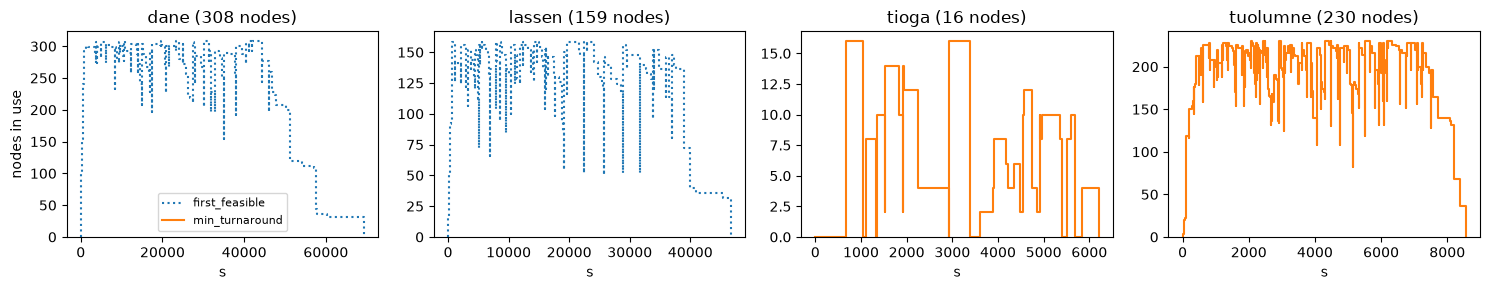

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(15, 3), sharey=False)
for ax, spec in zip(axes, FLEET):
    for rec, style, name in [(rec_ff, ":", "first_feasible"), (rec_mt, "-", "min_turnaround")]:
        r = rec[rec.platform == spec.name]
        events = sorted([(t, +n) for t, n in zip(r.begin_time, r.num_nodes)] +
                        [(t, -n) for t, n in zip(r.end_time, r.num_nodes)])
        ts, occ, cur = [0], [0], 0
        for t, d in events:
            cur += d; ts.append(t); occ.append(cur)
        ax.step(ts, occ, where="post", ls=style, label=name)
    ax.set(title=f"{spec.name} ({spec.total_nodes} nodes)", xlabel="s", ylim=(0, spec.total_nodes * 1.05))
axes[0].set_ylabel("nodes in use"); axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

In [9]:
server.terminate(); server.wait(timeout=10)
generated_dir.cleanup()
print("server stopped; session files:", len(list(SERVER_DIR.glob("*.simulated.csv"))))

server stopped; session files: 8


## What the real build adds on top of this skeleton

- **Windows.** Arrivals accumulate in a federation queue and are cleared every 30-60
  minutes instead of routed on arrival; the window policy reads dr_evt's free nodes.
- **Bids and the mechanism.** Each queued job carries a private `max_spend`; candidate
  placements are built with `predict_start` per platform; `decide_market` picks winners
  and charges; the Myerson quality integral and IR checks port unchanged.
- **Composite jobs.** Legs on different platforms, submitted only when every leg is
  predicted to start now; `partial_start` measured after the fact.
- **The event log.** Every decision and every record becomes an event with a canonical
  hash, and every metric is a fold over that log.
- **In-process adapter.** The same `GrpcPlatform` interface over `dr_evt.Simulation`, once
  the timing accessor makes per-job records available without a CSV round-trip.

## Exercises

1. Why does the controller advance every platform to each arrival time even though only
   one of them receives the job?
2. In `predict_start`, why is the ledger fallback needed, and what would make it wrong?
3. `min_turnaround` produced positive prediction errors on some platform. Name two
   mechanisms by which EASY starts a job later than the client predicted.
4. What guarantees that `records` rows map to ledger entries by position, and what single
   event breaks it?
5. Which parts of this notebook are already the market client's platform, controller, and
   metrics layers, and which part of the client has no counterpart here at all?